# Phase 1 — Exploration des données
## Bitext Retail + Bitext Customer Support

### Nouveauté par rapport à la version initiale
Ce notebook intègre **deux datasets Bitext** pour l'exploration :
- `bitext/Bitext-retail-ecommerce-llm-chatbot-training-dataset` — votre source principale
- `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — source complémentaire

**Objectif de l'exploration double :**
1. Comprendre la structure de chaque dataset séparément
2. Identifier les intents communs entre les deux → fusionnables
3. Identifier les intents uniques à chaque source → diversité
4. Analyser les tags linguistiques (M, K, B, Z...) dans les deux sources
5. Décider de la stratégie de fusion pour la Phase 2


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import re
import json
import os
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

BASE_DIR    = Path('D:/conv_nlp_pipeline')
DATA_RAW    = BASE_DIR / 'data/raw'
DATA_PROC   = BASE_DIR / 'data/processed'
DATA_SPLITS = BASE_DIR / 'data/splits'
for p in [DATA_RAW, DATA_PROC, DATA_SPLITS]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})
print('Imports OK ✓')


Imports OK ✓


In [2]:
# ── Charger Bitext Retail ─────────────────────────────────────
df_retail = pd.read_csv(DATA_RAW / 'bitext-retail.csv')
df_retail['source'] = 'retail'   # tag source pour traçabilité

# ── Charger Bitext Customer Support ──────────────────────────
# Télécharger depuis :
# https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset
# > Files and versions > train.csv → sauvegarder dans data/raw/bitext-support.csv
df_support = pd.read_csv(DATA_RAW / 'Bitext_Customer_Support.csv')
df_support['source'] = 'support'

print('=== Bitext Retail ===')
print(f'  Lignes      : {len(df_retail):,}')
print(f'  Colonnes    : {list(df_retail.columns)}')
print(f'  Intents     : {df_retail["intent"].nunique()}')
print(f'  Catégories  : {df_retail["category"].nunique()}')
print()
print('=== Bitext Customer Support ===')
print(f'  Lignes      : {len(df_support):,}')
print(f'  Colonnes    : {list(df_support.columns)}')
print(f'  Intents     : {df_support["intent"].nunique()}')
print(f'  Catégories  : {df_support["category"].nunique()}')


=== Bitext Retail ===
  Lignes      : 44,884
  Colonnes    : ['instruction', 'intent', 'category', 'tags', 'response', 'source']
  Intents     : 46
  Catégories  : 13

=== Bitext Customer Support ===
  Lignes      : 26,872
  Colonnes    : ['flags', 'instruction', 'category', 'intent', 'response', 'source']
  Intents     : 27
  Catégories  : 11


## 3. Analyse des intents — comparaison entre les deux sources

In [3]:
intents_retail  = set(df_retail['intent'].unique())
intents_support = set(df_support['intent'].unique())

common   = intents_retail & intents_support
only_retail  = intents_retail - intents_support
only_support = intents_support - intents_retail

print(f'Intents communs aux deux sources  : {len(common)}')
print(f'Intents uniques à Retail          : {len(only_retail)}')
print(f'Intents uniques à Customer Support: {len(only_support)}')
print()
print('--- Intents COMMUNS (fusionnables directement) ---')
for i in sorted(common): print(f'  {i}')
print()
print('--- Intents RETAIL uniquement ---')
for i in sorted(only_retail): print(f'  {i}')
print()
print('--- Intents SUPPORT uniquement ---')
for i in sorted(only_support): print(f'  {i}')


Intents communs aux deux sources  : 5
Intents uniques à Retail          : 41
Intents uniques à Customer Support: 22

--- Intents COMMUNS (fusionnables directement) ---
  cancel_order
  change_order
  payment_issue
  recover_password
  track_order

--- Intents RETAIL uniquement ---
  add_product
  availability
  availability_in_store
  availability_online
  change_account
  close_account
  customer_service
  damaged_delivery
  delivery_issue
  delivery_time
  exchange_product
  exchange_product_in_store
  human_agent
  missing_item
  open_account
  order_history
  pay
  payment_methods
  product_information
  product_issue
  refund_policy
  refund_status
  remove_product
  request_invoice
  request_refund
  request_right_to_rectification
  return_policy
  return_product
  return_product_in_store
  return_product_online
  sales_period
  shipping_costs
  store_location
  store_opening_hours
  submit_feedback
  submit_product_feedback
  submit_product_idea
  technical_issue
  track_deliver

## 4. Visualisation — Distribution par source

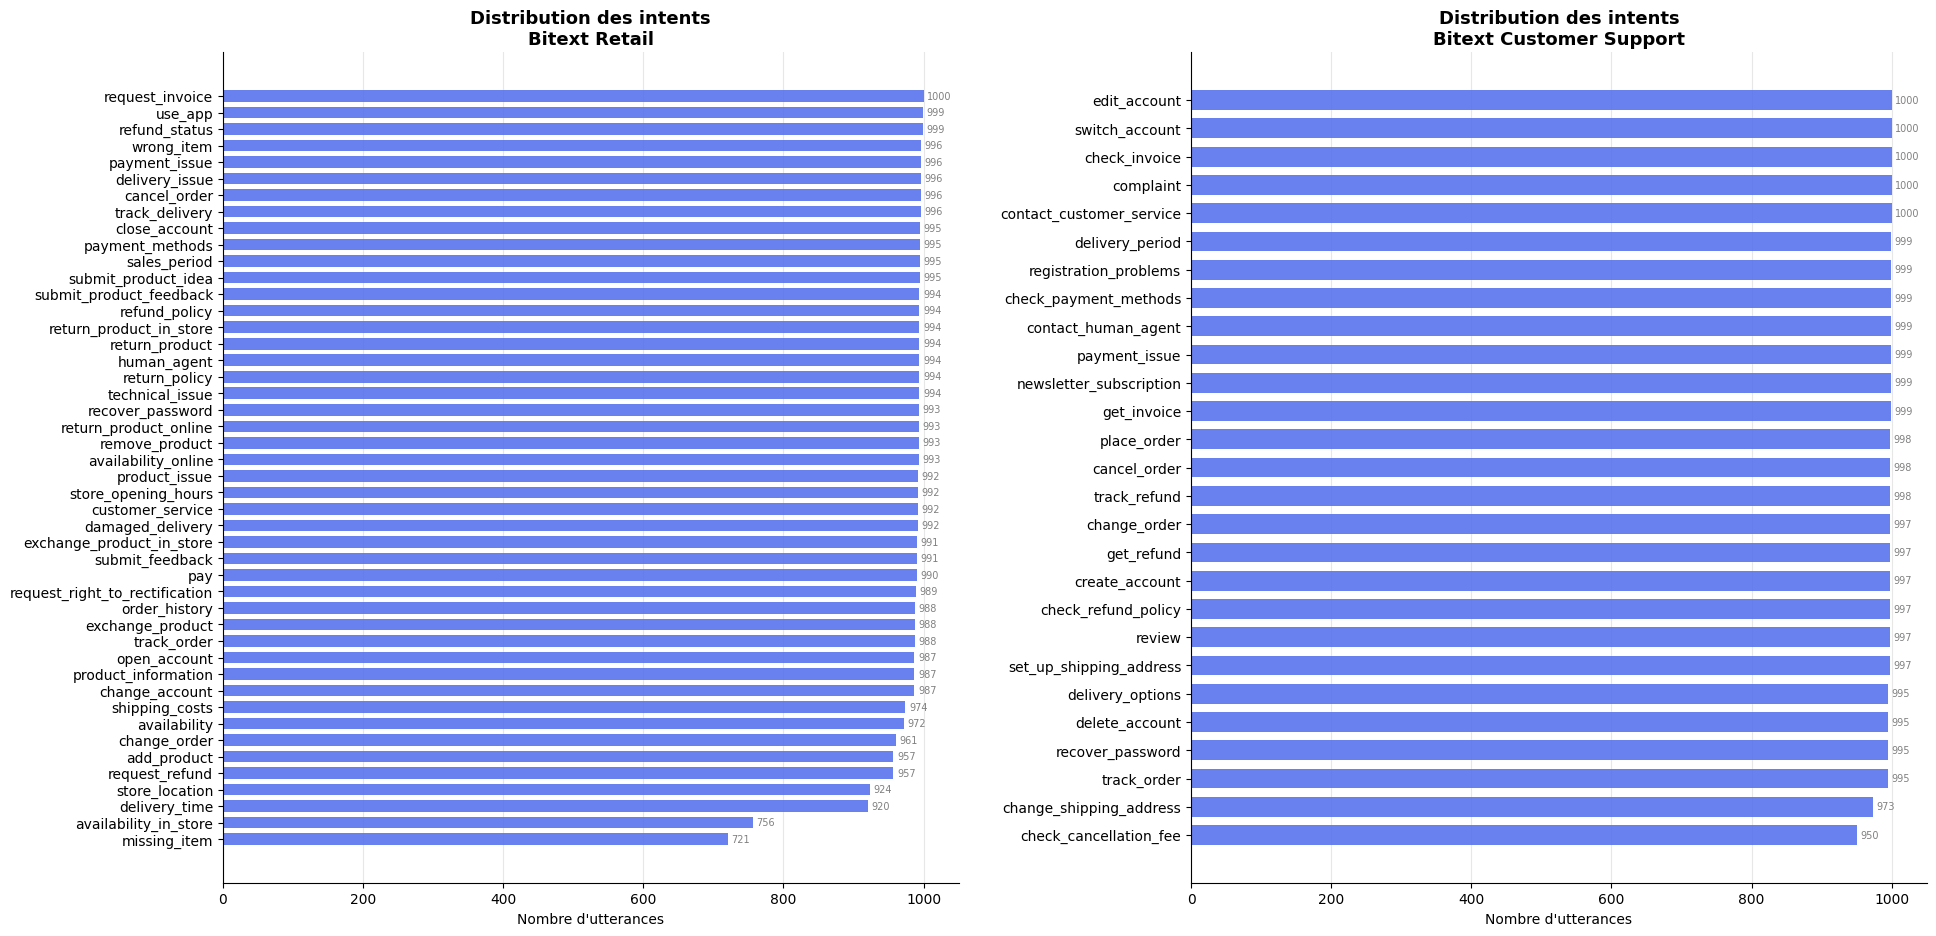

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

for ax, (df_, title) in zip(axes, [
    (df_retail,  'Bitext Retail'),
    (df_support, 'Bitext Customer Support')
]):
    ax.set_facecolor('white')
    counts = df_['intent'].value_counts().sort_values()
    ax.barh(counts.index, counts.values, color='#4F6BED', height=0.7, alpha=0.85)
    for i, val in enumerate(counts.values):
        ax.text(val + 5, i, str(val), va='center', fontsize=7, color='gray')
    ax.set_title(f'Distribution des intents\n{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel("Nombre d'utterances")
    ax.spines[['top','right']].set_visible(False)
    ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout(pad=3)
plt.savefig(DATA_PROC / 'fig_intents_both_sources.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Analyse des tags linguistiques dans les deux sources

Tags Retail  : {'BCILPQWZ': 1082, 'BCILPWZ': 1078, 'BCILPW': 1021, 'BCILPQZ': 1015, 'BCILPQW': 1008, 'BCILPZ': 993, 'BCILPQ': 980, 'BCILP': 962, 'BCILWZ': 851, 'BCILQZ': 840, 'BCILQWZ': 829, 'BCILW': 804, 'BCILQW': 785, 'BCILZ': 766, 'BCILQ': 725, 'BCIL': 699, 'BCIPZ': 545, 'BCIPQZ': 537, 'BCLQWZ': 499, 'BCIPQ': 486, 'BCIP': 486, 'BCLWZ': 473, 'BCLQZ': 452, 'BCLZ': 436, 'BCLW': 423, 'BCIZ': 420, 'BCIPQWZ': 417, 'BCIPWZ': 410, 'BCLQ': 409, 'BCIPW': 406, 'BCLQW': 401, 'BCL': 400, 'BCIPQW': 397, 'BCIQZ': 370, 'BCIQ': 350, 'BCI': 323, 'BCIW': 311, 'BCIWZ': 299, 'BLW': 284, 'BCIQW': 283, 'BCIQWZ': 275, 'BLWZ': 275, 'BLZ': 270, 'BCILMPQW': 253, 'BL': 251, 'BCILMPWZ': 237, 'BLQWZ': 229, 'BCILMPQWZ': 223, 'BCILMPW': 218, 'BLQZ': 211, 'BILW': 210, 'BCILMP': 205, 'BCILMPZ': 200, 'BILQZ': 200, 'BLQW': 199, 'BILZ': 199, 'BCILMQWZ': 198, 'BCILMQZ': 197, 'BILQ': 196, 'BCILMQW': 192, 'BCILMPQZ': 190, 'BILWZ': 190, 'BIL': 188, 'BCILMWZ': 185, 'BZ': 183, 'BLQ': 183, 'BCLPW': 178, 'BCILMW': 177, 'BCILMP

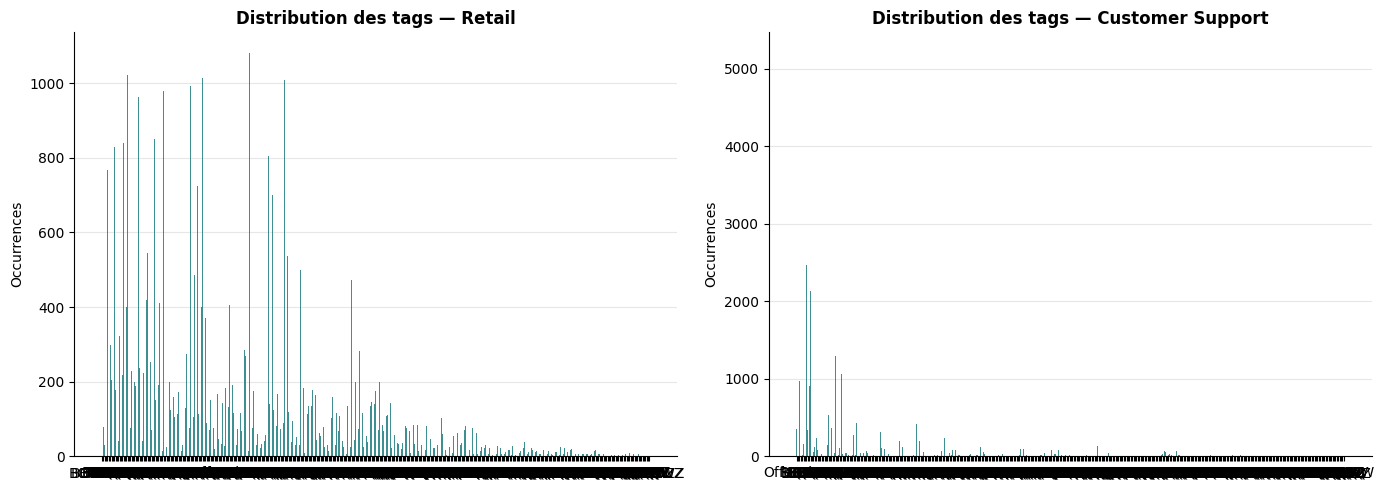

In [5]:
# Les tags Bitext encodent les variations linguistiques :
# M = colloquial  K = typos  B = offensive  Z = code-switching
# W = offensive/taboo  P = pronoun variation  E = emphasis

def parse_tags(flags_series):
    """Extrait tous les tags individuels depuis la colonne flags."""
    all_tags = []
    for val in flags_series.dropna().astype(str):
        all_tags.extend([t.strip() for t in val.split(',') if t.strip()])
    return Counter(all_tags)

tags_retail  = parse_tags(df_retail['flags']  if 'flags'  in df_retail.columns
                          else df_retail['tags'] if 'tags' in df_retail.columns
                          else pd.Series())
tags_support = parse_tags(df_support['flags'] if 'flags' in df_support.columns
                          else df_support['tags'] if 'tags' in df_support.columns
                          else pd.Series())

TAG_LABELS = {
    'M': 'Colloquial', 'K': 'Typos', 'B': 'Offensive',
    'Z': 'Code-switching', 'W': 'Taboo', 'P': 'Pronoun var.', 'E': 'Emphasis'
}

print('Tags Retail  :', dict(tags_retail.most_common()))
print('Tags Support :', dict(tags_support.most_common()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
for ax, (tags, title) in zip(axes, [
    (tags_retail,  'Retail'),
    (tags_support, 'Customer Support')
]):
    ax.set_facecolor('white')
    if tags:
        keys   = [TAG_LABELS.get(k, k) for k in tags.keys()]
        values = list(tags.values())
        ax.bar(keys, values, color='#0D7377', alpha=0.8, width=0.5)
        ax.set_title(f'Distribution des tags — {title}', fontweight='bold')
        ax.set_ylabel('Occurrences')
        ax.spines[['top','right']].set_visible(False)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_tags_both_sources.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Décision de fusion — ce qu'on garde

Sur la base de l'exploration ci-dessus, voici la stratégie adoptée en Phase 2 :

| Intents communs | → **Fusionner** les deux sources · double le volume · double la variété |
|---|---|
| Intents Retail uniquement | → **Garder** tels quels |
| Intents Support uniquement | → **Garder** si thématiquement proches du e-commerce |

Le dataset fusionné sera le train set d'entraînement.  
Le test set Bitext Retail reste **intact** comme référence synthétique.  
Le test externe (Banking77) sera le vrai indicateur de robustesse.


In [6]:
# Résumé de ce qui sera fusionné
print('DÉCISION DE FUSION')
print('='*50)
print(f'Intents communs fusionnés  : {len(common)}')
print(f'  → volume doublé sur ces intents')
print(f'  → variété linguistique doublée')
print()
print(f'Intents Retail uniquement  : {len(only_retail)}')
print(f'  → conservés tels quels')
print()
print(f'Intents Support uniquement : {len(only_support)}')
print(f'  → à filtrer manuellement selon pertinence e-commerce')
print()
print(f'Total intents final estimé : {len(intents_retail | intents_support)}')


DÉCISION DE FUSION
Intents communs fusionnés  : 5
  → volume doublé sur ces intents
  → variété linguistique doublée

Intents Retail uniquement  : 41
  → conservés tels quels

Intents Support uniquement : 22
  → à filtrer manuellement selon pertinence e-commerce

Total intents final estimé : 68
